In [153]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

import ast

In [154]:
df = pd.read_csv('dataset/top_movies_tmdb_cleaned.csv')

In [155]:
genres = df['genres'].apply(lambda x: ast.literal_eval(x)).explode()

genres_presence = (
    genres
    .to_frame('genres')
    .assign(id=lambda x: x.index)
    .assign(present=1)
    .pivot_table(values='present', index='id', columns='genres', aggfunc='max', fill_value=0)
)
genres_presence.head()

genres,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
id,,,,,,,,,,,,,,,,,,,
0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0
4,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [156]:
corr = genres_presence.corr()

mask = np.triu(np.ones_like(corr, dtype=np.bool), k=1)
corr = np.ma.array(corr, mask=mask)

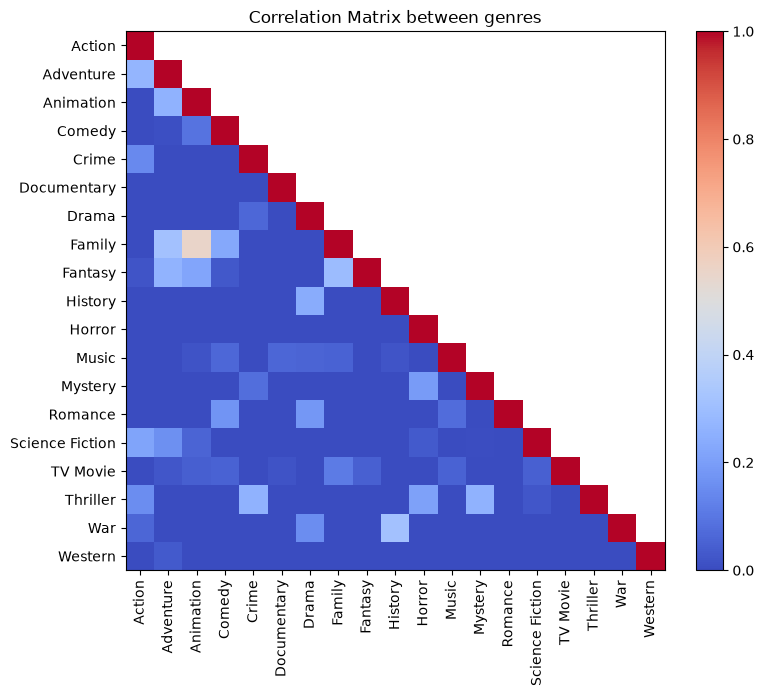

In [157]:
fig, ax = plt.subplots(figsize=(10, 7), dpi=100)
img = ax.imshow(corr, cmap='coolwarm', vmin=0, vmax=1)

n = corr.shape[0]
columns = genres_presence.columns.to_list()

ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))

ax.set_xticklabels(columns, rotation=90)
ax.set_yticklabels(columns)

ax.set_title('Correlation Matrix between genres')

fig.colorbar(img, ax=ax, fraction=0.046, pad=0.04)

Text(0, 0.5, 'Genre')

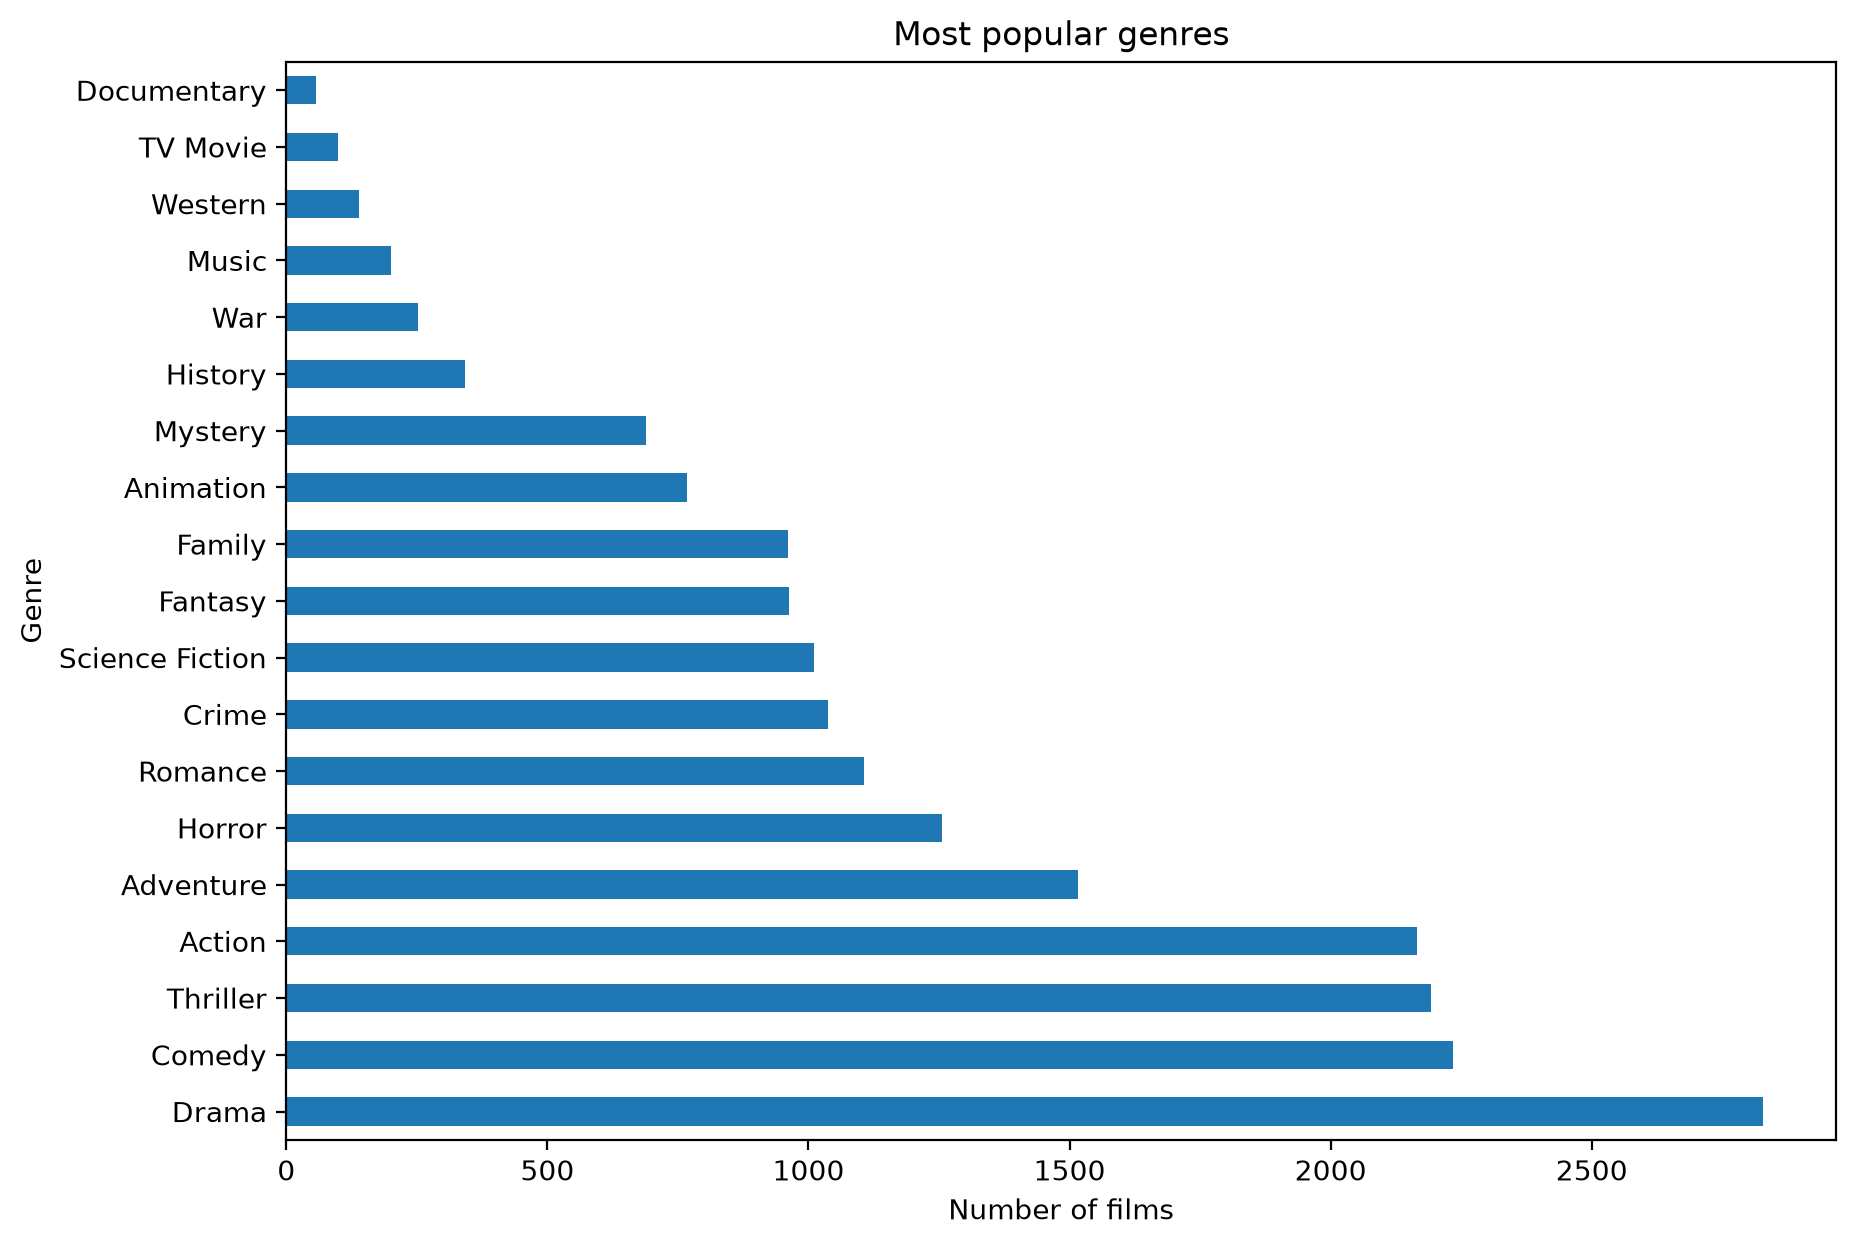

In [158]:
plt.figure(figsize=(10, 7), dpi=200)

ax = genres.value_counts().plot.barh()
ax.set_title('Most popular genres')
ax.set_xlabel('Number of films')
ax.set_ylabel('Genre')

In [159]:
releases_per_year = (
    df['release_date']
    .apply(lambda x: int(x[:4]))
    .value_counts()
    .sort_index(ascending=False)
    .to_frame('releases')
    .assign(year=lambda x: x.index)
    .to_numpy()
)
releases, years = releases_per_year.T

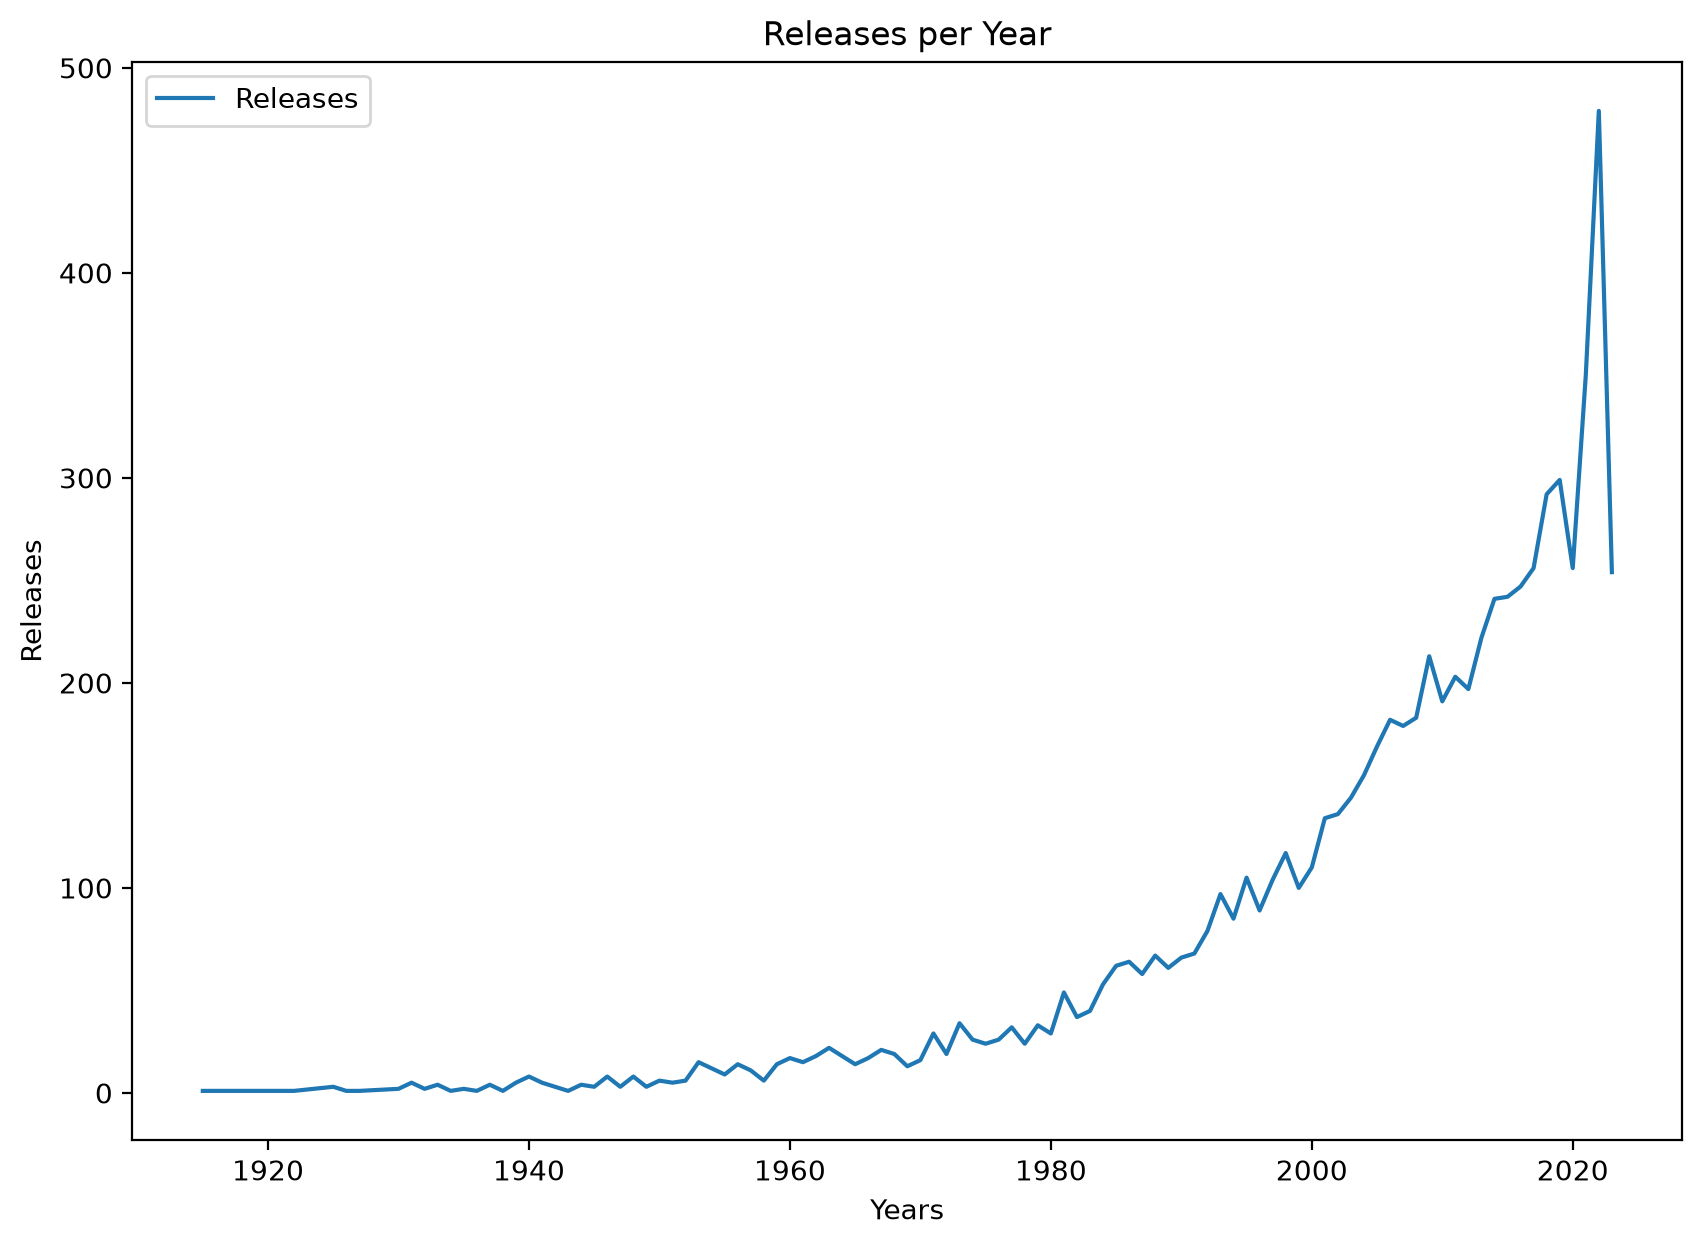

In [160]:
plt.figure(figsize=(10, 7), dpi=200)

plt.title('Releases per Year')
plt.plot(years, releases, label='Releases')

plt.xlabel('Years')
plt.ylabel('Releases')

plt.legend()

In [161]:
votes_df = df[['release_date', 'vote_average']]
votes_df['release_year'] = votes_df['release_date'].apply(lambda x: x[:4])
votes_df = votes_df.drop('release_date', axis=1).sort_values('release_year')

mean_votes_per_year = votes_df.groupby('release_year').agg({'vote_average': np.mean})

mean_votes, years = mean_votes_per_year.assign(year=lambda x: x.index).to_numpy().T

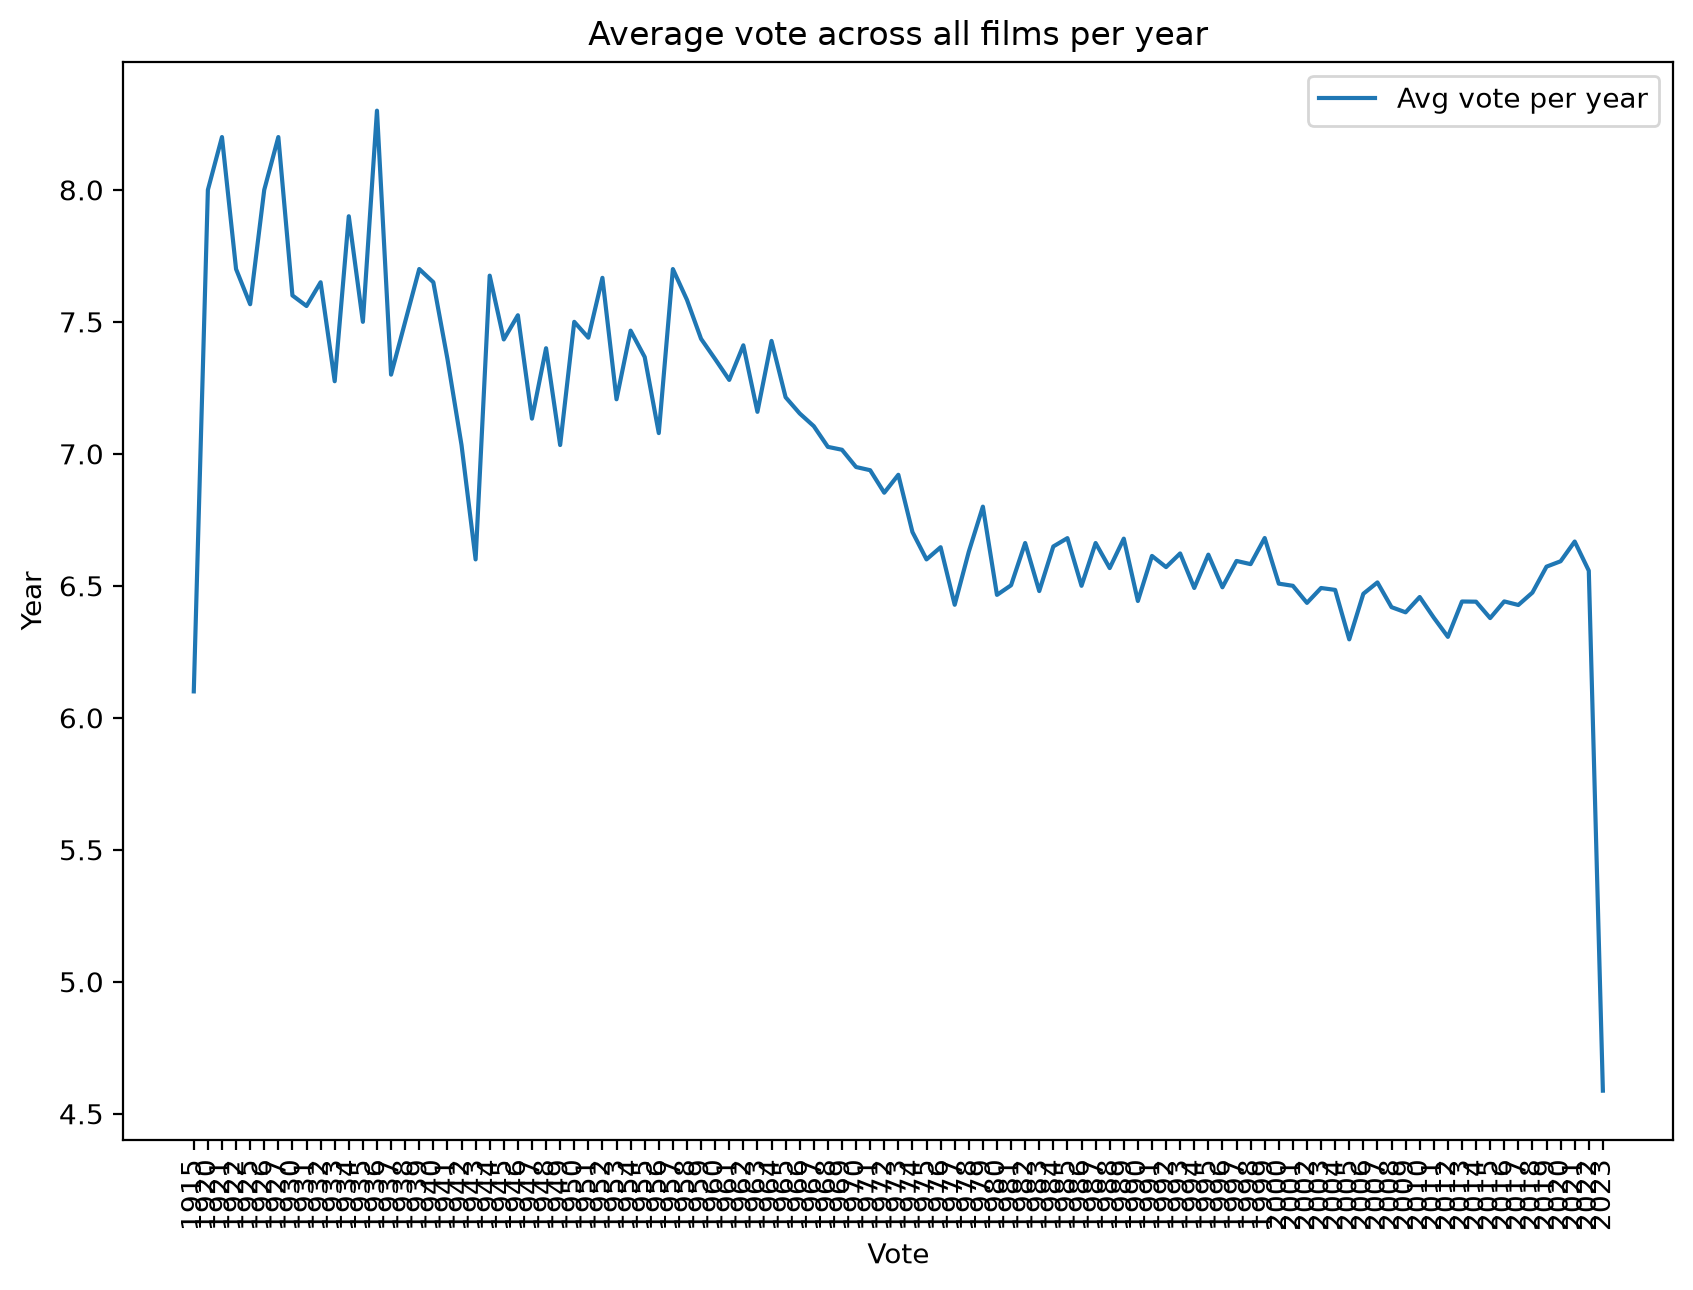

In [162]:
plt.figure(figsize=(10, 7), dpi=200)

plt.title('Average vote across all films per year')
plt.plot(years, mean_votes, label='Avg vote per year')

plt.xlabel('Vote')
plt.ylabel('Year')

plt.tick_params(axis='x', rotation=90)
plt.legend()

Text(0.5, 0, 'Number of films')

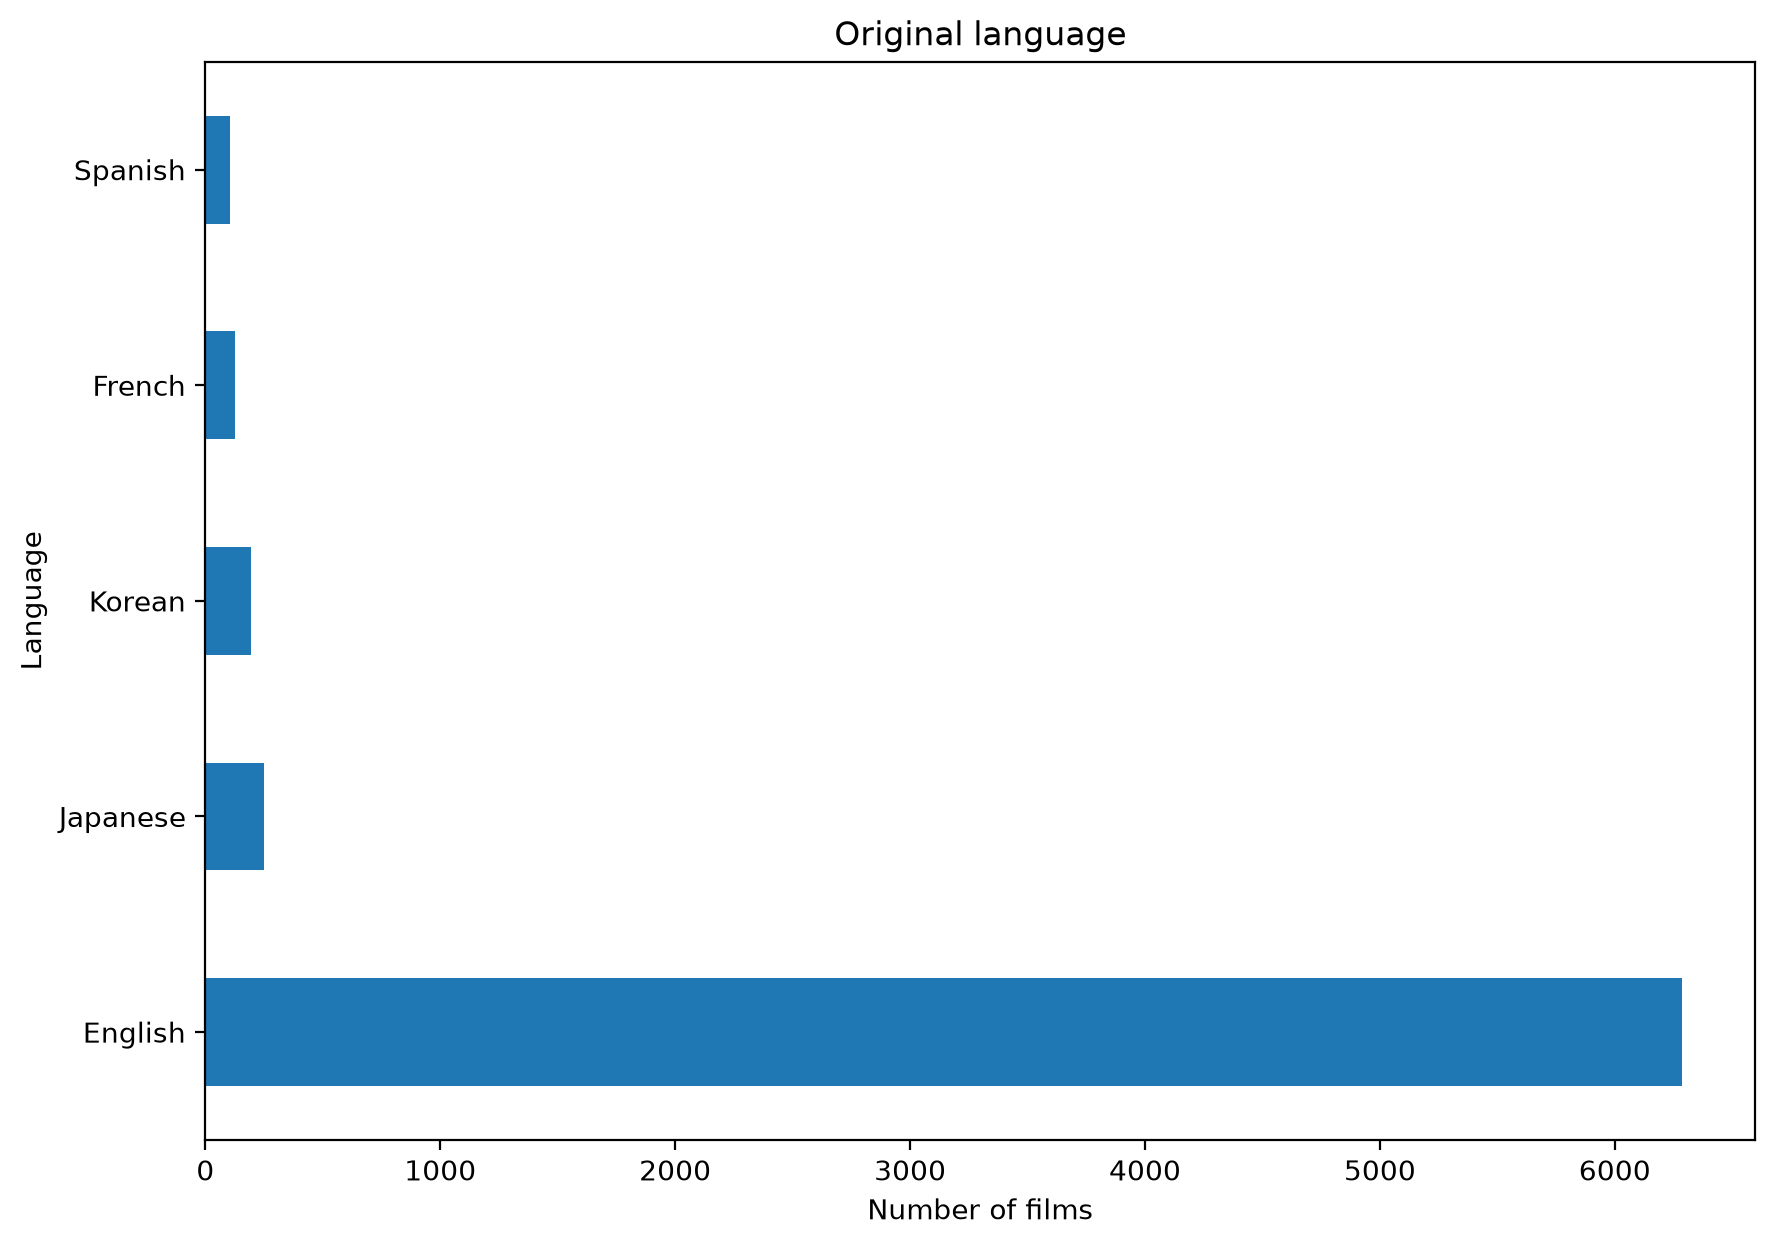

In [163]:
fig = plt.figure(figsize=(10, 7), dpi=200)

ax = df['original_language'].value_counts().head().plot.barh()
ax.set_title('Original language')
ax.set_ylabel('Language')
ax.set_xlabel('Number of films')